In [1]:
from oggm.shop import bedtopo
from oggm import workflow
import xarray as xr  # Import xarray 
import matplotlib.pyplot as plt


In [2]:
from oggm import cfg, utils, workflow, tasks, graphics
cfg.initialize(logging_level='WARNING')

2025-01-08 14:02:48: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-08 14:02:48: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-08 14:02:48: oggm.cfg: Multiprocessing: using all available processors (N=16)


In [3]:
# Local working directory (where OGGM will write its output)
# WORKING_DIR = utils.gettempdir('OGGM_distr4')
cfg.PATHS['working_dir'] = '/home/usman/Music/GeeMap /OGGM/data'

In [4]:
rgi_ids = ['RGI60-14.02192']  # Fieschergletscher

In [5]:
# The RGI version to use
# Size of the map around the glacier.
prepro_border = 10
# Degree of processing level. This is OGGM specific and for the shop 1 is the one you want
from_prepro_level = 3
# URL of the preprocessed gdirs
# we use elevation bands flowlines here
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5'
gdirs = workflow.init_glacier_directories(rgi_ids,
                                          from_prepro_level=from_prepro_level,
                                          prepro_base_url=base_url,
                                          prepro_border=prepro_border)

2025-01-08 14:02:49: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-01-08 14:02:49: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [6]:
gdir = gdirs[0]

In [7]:
from oggm.shop import bedtopo

In [8]:
workflow.execute_entity_task(bedtopo.add_consensus_thickness, gdirs);

2025-01-08 14:02:50: oggm.workflow: Execute entity tasks [add_consensus_thickness] on 1 glaciers


In [9]:

with xr.open_dataset(gdir.get_filepath('gridded_data')) as ds:
    ds = ds.load()


In [15]:
print(ds)

<xarray.Dataset> Size: 300kB
Dimensions:                  (x: 178, y: 112)
Coordinates:
  * x                        (x) float32 712B -1.459e+04 ... 9.662e+03
  * y                        (y) float32 448B 4.06e+06 4.06e+06 ... 4.045e+06
Data variables:
    topo                     (y, x) float32 80kB 3.961e+03 ... 4.164e+03
    topo_smoothed            (y, x) float32 80kB 3.948e+03 ... 4.171e+03
    topo_valid_mask          (y, x) int8 20kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    glacier_mask             (y, x) int8 20kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    glacier_ext              (y, x) int8 20kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    consensus_ice_thickness  (y, x) float32 80kB nan nan nan nan ... nan nan nan
Attributes:
    author:         OGGM
    author_info:    Open Global Glacier Model
    pyproj_srs:     +proj=tmerc +lat_0=0 +lon_0=74.2238 +k=0.9996 +x_0=0 +y_0...
    max_h_dem:      7109.0
    min_h_dem:      2695.0
    max_h_glacier:  7013.0
    min_h_glacier:  2886.0


In [10]:
# plot the salem map background, make countries in grey
smap = ds.salem.get_map(countries=False)
smap.set_shapefile(gdir.read_shapefile('outlines'))
smap.set_topography(ds.topo.data);

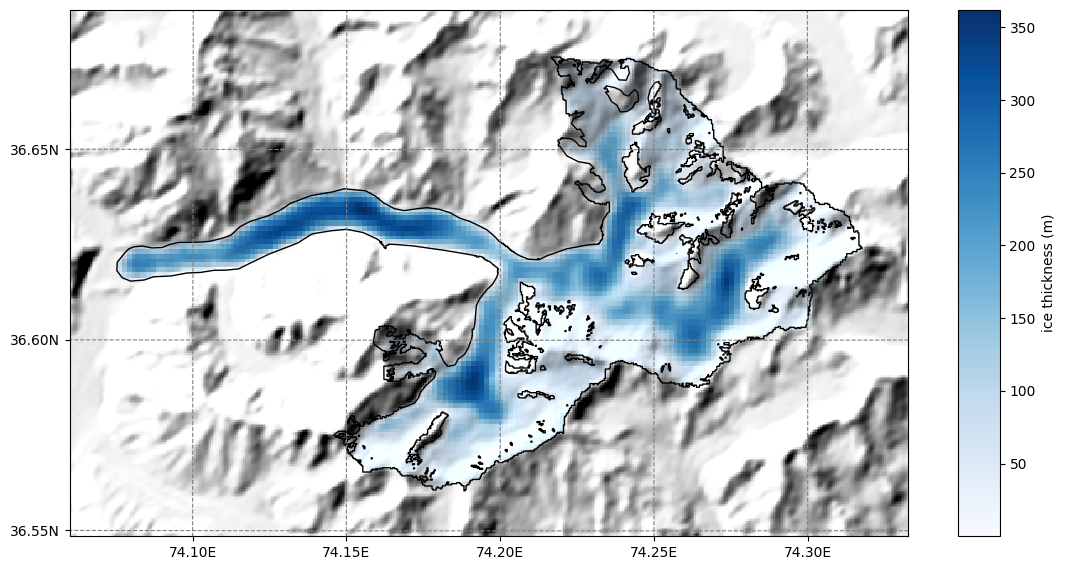

In [17]:
f, ax = plt.subplots(figsize=(12, 12))
smap.set_data(ds.consensus_ice_thickness)
smap.set_cmap('Blues')
smap.plot(ax=ax)
smap.append_colorbar(ax=ax, label='ice thickness (m)');
plt.savefig('/home/usman/Music/GeeMap/Results/ice_thickness_plot.png', dpi=500, bbox_inches='tight')


In [21]:
# attention downloads data!!!
from oggm.shop import millan22
workflow.execute_entity_task(millan22.velocity_to_gdir, gdirs);

2025-01-08 14:10:39: oggm.workflow: Execute entity tasks [velocity_to_gdir] on 1 glaciers


In [22]:
with xr.open_dataset(gdir.get_filepath('gridded_data')) as ds:
    ds = ds.load()
ds

<xarray.Dataset> Size: 539kB
Dimensions:                  (x: 178, y: 112)
Coordinates:
  * x                        (x) float32 712B -1.459e+04 ... 9.662e+03
  * y                        (y) float32 448B 4.06e+06 4.06e+06 ... 4.045e+06
Data variables:
    topo                     (y, x) float32 80kB 3.961e+03 ... 4.164e+03
    topo_smoothed            (y, x) float32 80kB 3.948e+03 ... 4.171e+03
    topo_valid_mask          (y, x) int8 20kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    glacier_mask             (y, x) int8 20kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    glacier_ext              (y, x) int8 20kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    consensus_ice_thickness  (y, x) float32 80kB nan nan nan nan ... nan nan nan
    millan_v                 (y, x) float32 80kB 0.0 0.0 0.0 ... 124.0 141.3
    millan_vx                (y, x) float32 80kB nan nan nan ... -48.67 -53.18
    millan_vy                (y, x) float32 80kB nan nan nan ... -114.0 -130.9
Attributes:
    author:         OGGM
    author_info:    Open Global Glacier Model
    pyproj_srs:     +proj=tmerc +lat_0=0 +lon_0=74.2238 +k=0.9996 +x_0=0 +y_0...
    max_h_dem:      7109.0
    min_h_dem:      2695.0
    max_h_glacier:  7013.0
    min_h_glacier:  2886.0

In [23]:
# plot the salem map background, make countries in grey
smap = ds.salem.get_map(countries=False)
smap.set_shapefile(gdir.read_shapefile('outlines'))
smap.set_topography(ds.topo.data);

In [24]:
ds

<xarray.Dataset> Size: 539kB
Dimensions:                  (x: 178, y: 112)
Coordinates:
  * x                        (x) float32 712B -1.459e+04 ... 9.662e+03
  * y                        (y) float32 448B 4.06e+06 4.06e+06 ... 4.045e+06
Data variables:
    topo                     (y, x) float32 80kB 3.961e+03 ... 4.164e+03
    topo_smoothed            (y, x) float32 80kB 3.948e+03 ... 4.171e+03
    topo_valid_mask          (y, x) int8 20kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    glacier_mask             (y, x) int8 20kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    glacier_ext              (y, x) int8 20kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    consensus_ice_thickness  (y, x) float32 80kB nan nan nan nan ... nan nan nan
    millan_v                 (y, x) float32 80kB 0.0 0.0 0.0 ... 124.0 141.3
    millan_vx                (y, x) float32 80kB nan nan nan ... -48.67 -53.18
    millan_vy                (y, x) float32 80kB nan nan nan ... -114.0 -130.9
Attributes:
    author:         OGGM
    author_info:    Open Global Glacier Model
    pyproj_srs:     +proj=tmerc +lat_0=0 +lon_0=74.2238 +k=0.9996 +x_0=0 +y_0...
    max_h_dem:      7109.0
    min_h_dem:      2695.0
    max_h_glacier:  7013.0
    min_h_glacier:  2886.0

In [25]:
# get the velocity data
u = ds.millan_vx.where(ds.glacier_mask)
v = ds.millan_vy.where(ds.glacier_mask)
ws = (u**2 + v**2)**0.5

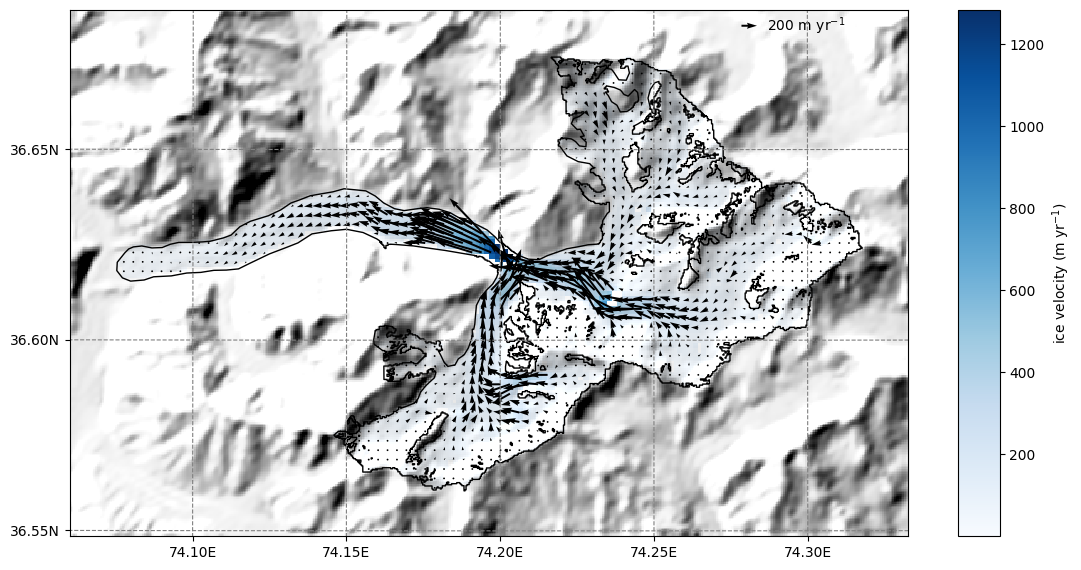

In [26]:
import numpy as np 

# get the axes ready
f, ax = plt.subplots(figsize=(12, 12))

# Quiver only every 3rd grid point
us = u[1::2, 1::2]
vs = v[1::2, 1::2]

smap.set_data(ws)
smap.set_cmap('Blues')
smap.plot(ax=ax)
smap.append_colorbar(ax=ax, label = 'ice velocity (m yr$^{-1}$)')

# transform their coordinates to the map reference system and plot the arrows
xx, yy = smap.grid.transform(us.x.values, us.y.values, crs=gdir.grid.proj)
xx, yy = np.meshgrid(xx, yy)
qu = ax.quiver(xx, yy, us.values, vs.values)
qk = ax.quiverkey(qu, 0.82, 0.97, 200, '200 m yr$^{-1}$',
                   labelpos='E', coordinates='axes')


plt.savefig('/home/usman/Music/GeeMap/Results/ice_velocity_plot.png', dpi=500, bbox_inches='tight')

In [27]:
pwd

'/home/usman/Music/GeeMap /OGGM'